# 1次元トポロジカル絶縁体：SSH模型の実装

## Reference

J. K. Asbóth, L. Oroszlány, and A. Pályi, *A Short Course on Topological Insulators: Band-Structure Topology and Edge States in One and Two Dimensions*, Lecture Notes in Physics **919** (Springer, 2016). [doi:10.1007/978-3-319-25607-8](https://doi.org/10.1007/978-3-319-25607-8); [arXiv:1509.02295](https://arxiv.org/abs/1509.02295).

## 概要

Su-Schrieffer-Heeger (SSH) 模型の略称。<br>
下図のような1次元の格子模型で、単位セルあたり 2 つのサイトAおよびBを持つ。<br>
サイト間の結合として最近接項のみを考慮している。（Tight-binding model）

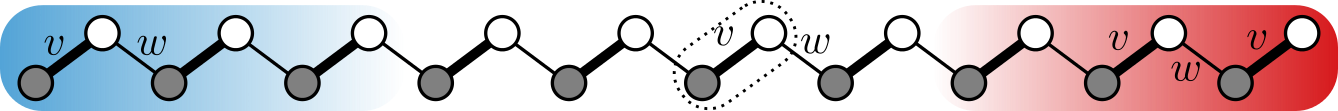

SSH模型はシンプルな模型であるが、トポロジカル絶縁体の物理を理解するうえで重要である。
また、一部のメタマテリアルやフォトニック結晶の系においては、SSHモデルによってその物性を理解できる場合もある。（逆に、SSHで表せるようなシンプルな構造を実装する、という発想で構造を設計することもある。）

## ハミルトニアンと固有値

### On-site 基底による表現

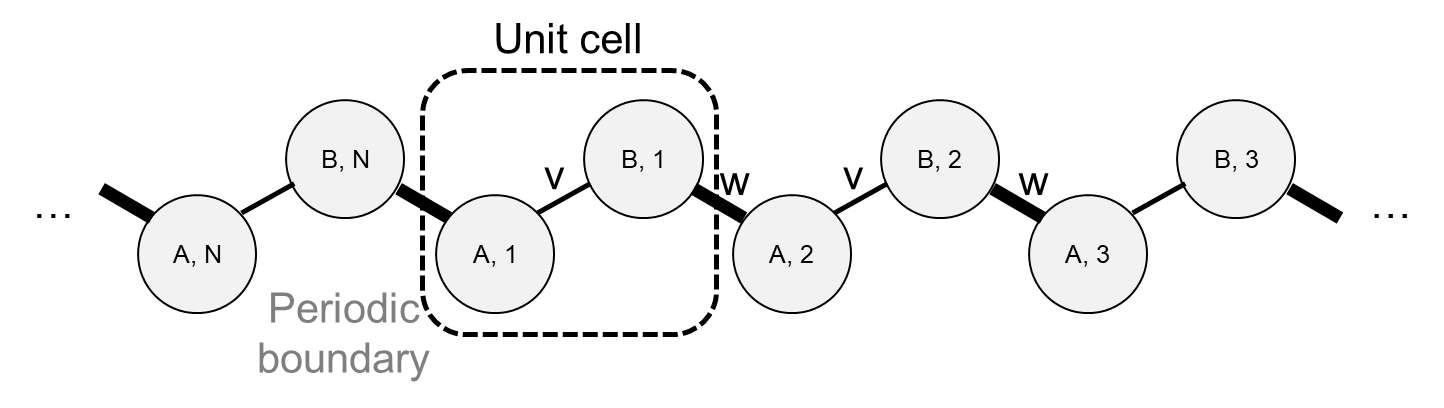

格子のサイト数を$N$として、このモデルのハミルトニアンはOn-siteの基底を用いて以下のように表される。

$$
\begin{aligned}
H &= v \sum_{l=1}^{N} \left( \lvert l, B \rangle{} \langle l, A \rvert{} + \lvert l, A \rangle{} \langle l, B \rvert{} \right) 
+ w \sum_{l=1}^{N} \left(\lvert l+1, A \rangle{} \langle l, B \rvert{} + \lvert l, B \rangle{} \langle l+1, A \rvert{} \right) \\
&=: H_\mathrm{intra} + H_\mathrm{inter}
\end{aligned}
$$

- $v$: ユニットセル内の相互作用
- $w$: ユニットセル間の相互作用

例えば、$N=4$ のときは次のような行列で表される。

$$
\begin{aligned}
H = \begin{bmatrix}
0 & v & 0 & 0 & 0 & 0 & 0 & 0 \\
v & 0 & w & 0 & 0 & 0 & 0 & 0 \\
0 & w & 0 & v & 0 & 0 & 0 & 0 \\
0 & 0 & v & 0 & w & 0 & 0 & 0 \\
0 & 0 & 0 & w & 0 & v & 0 & 0 \\
0 & 0 & 0 & 0 & v & 0 & w & 0 \\
0 & 0 & 0 & 0 & 0 & w & 0 & v \\
0 & 0 & 0 & 0 & 0 & 0 & v & 0
\end{bmatrix}
\end{aligned}
$$

上記はOpen boundary condition $\lvert N+1, A \rangle{} = 0$ を課した場合。
周期境界条件 $\lvert N+1, A \rangle{} = \lvert 1, A \rangle{}$ が課されている場合、$H_{1,2N}=H_{2N,1}=w$ となる。

固有値問題 $H \lvert \Psi_n \rangle{} = E_n \lvert \Psi_n \rangle{}$ を解くことで、エネルギースペクトルを求めることができる。


### 平面波基底による表現

周期境界条件の下では、各サブ格子 \(\alpha\in\{A,B\}\) に対して

$$
\lvert k,\alpha\rangle
=\frac{1}{\sqrt{N}}\sum_{l=1}^{N}e^{ikl}\lvert l,\alpha\rangle,
\qquad
k=\frac{2\pi n}{N},\quad n=0,1,\ldots,N-1
$$

と定義する。基底を \((\lvert k,A\rangle,\lvert k,B\rangle)\) の順に取ると、Bloch Hamiltonian は

$$
H(k)=
\begin{bmatrix}
0 & v+w e^{-ik}\\
v+w e^{ik} & 0
\end{bmatrix}
=
\begin{bmatrix}
0 & h(k)^*\\
h(k) & 0
\end{bmatrix},
\qquad
h(k)=v+w e^{ik}
$$

となる。したがって、バンドギャップは \(h(k)=0\) のときに閉じる。標準的な \(v,w>0\) の場合、転移点は \(v=w\)、波数は \(k=\pi\) である。


### 固有値と固有ベクトル

\(h(k)=\lvert h(k)\rvert e^{i\phi(k)}\) と書くと、固有値と規格化固有ベクトルは

$$
E_\pm(k)=\pm\lvert h(k)\rvert
=\pm\sqrt{v^2+w^2+2vw\cos k},
$$

$$
\lvert u_\pm(k)\rangle
=\frac{1}{\sqrt{2}}
\begin{bmatrix}
1\\
\pm e^{i\phi(k)}
\end{bmatrix},
\qquad
\phi(k)=\operatorname{Arg}\!\left(v+w e^{ik}\right)
=\operatorname{atan2}\!\left(w\sin k,\,v+w\cos k\right).
$$

単純な \(\arctan(y/x)\) では象限と分岐を正しく追えないため、数値計算では \(\operatorname{atan2}\) または複素偏角を用いる。ギャップ閉鎖点では \(h(k)=0\) となり、\(\phi(k)\) と上の固有ベクトル表示は定義できない。


## 対称性とトポロジカル不変量

うろ覚えでかなりいい加減なことを書いているので、詳しくはその手のちゃんとしたテキストを参照すること。

### Chiral symmetry

Bloch Hamiltonian は

$$
H(k)=d_x(k)\sigma_x+d_y(k)\sigma_y,
\qquad
d_x(k)=v+w\cos k,\quad d_y(k)=w\sin k,
$$

と書け、\(\sigma_z\) 成分を持たない。このため

$$
\{\sigma_z,H(k)\}=0
\qquad\Longleftrightarrow\qquad
\sigma_zH(k)\sigma_z^{-1}=-H(k)
$$

が成り立つ。これがカイラル対称性である。\(\sigma_z=\operatorname{diag}(1,-1)\) は A/B サブ格子を交換する操作ではなく、両サブ格子に相対的な符号を与える操作である。A/B の交換は \(\sigma_x\) に対応する。
### Winding number

ギャップが開いている \(h(k)\neq0\) の場合、\(k\) が Brillouin zone を一周するときの複素数 \(h(k)=\lvert h(k)\rvert e^{i\phi(k)}\) の巻き付き数を

$$
\nu
=\frac{1}{2\pi i}\int_{-\pi}^{\pi}
\frac{\mathrm{d}}{\mathrm{d}k}\log h(k)\,\mathrm{d}k
=\frac{1}{2\pi}\int_{-\pi}^{\pi}
\frac{\partial\phi(k)}{\partial k}\,\mathrm{d}k
$$

で定義する。\(\nu\) は、\(h(k)\) の閉曲線が複素平面の原点を向き付きで何周するかを表す整数である。

標準的な実数結合 \(v,w>0\) では

$$
\nu=
\begin{cases}
0, & v>w \quad\text{(trivial)},\\
1, & v<w \quad\text{(topological)},
\end{cases}
$$

であり、\(v=w\) ではギャップが閉じるため winding number は定義できない。一般の符号を許す場合は \(\lvert w\rvert\) と \(\lvert v\rvert\) の大小に加えて、曲線の向きによって \(\nu\) の符号も変わり得る。

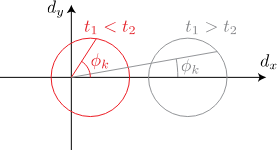

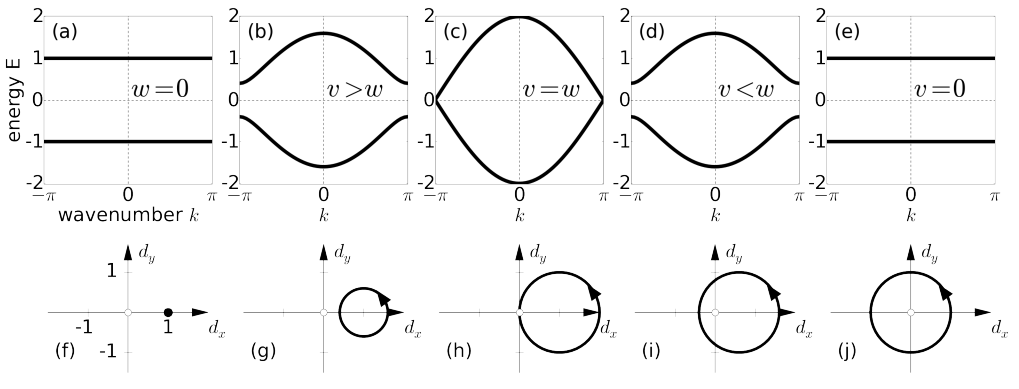

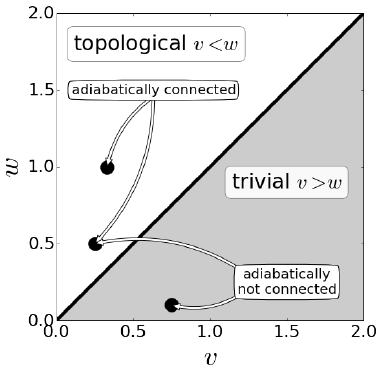

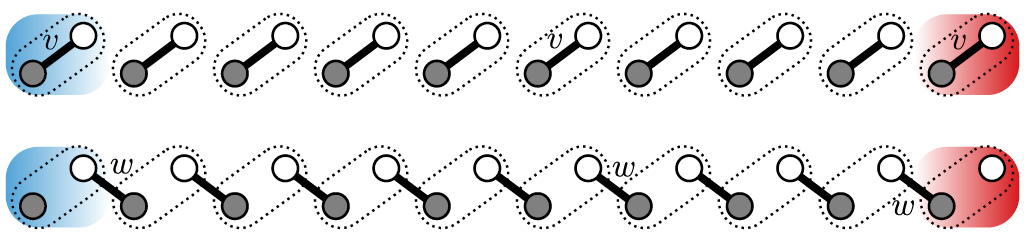


### Zak phase

ここでは Berry connection を

$$
A_\pm(k)
=-i\left\langle u_\pm(k)\middle|\frac{\partial}{\partial k}\middle|u_\pm(k)\right\rangle
$$

と定義し、Zak phase を

$$
\gamma_\pm=\int_{-\pi}^{\pi}A_\pm(k)\,\mathrm{d}k
\qquad (\mathrm{mod}\ 2\pi)
$$

とする。上の固有ベクトルでは

$$
\left\langle u_\pm(k)\middle|\frac{\partial}{\partial\phi}\middle|u_\pm(k)\right\rangle
=\frac{i}{2}
$$

なので、

$$
\begin{aligned}
\gamma_\pm
&=-i\int_{-\pi}^{\pi}
\frac{\partial\phi}{\partial k}
\left\langle u_\pm(k)\middle|\frac{\partial}{\partial\phi}\middle|u_\pm(k)\right\rangle
\,\mathrm{d}k\\
&=\frac{1}{2}\int_{-\pi}^{\pi}
\frac{\partial\phi}{\partial k}\,\mathrm{d}k\\
&=\pi\nu\qquad (\mathrm{mod}\ 2\pi).
\end{aligned}
$$

したがって、このゲージと単位胞の取り方では \(\nu=1\) のとき \(\gamma_\pm=\pi\)、\(\nu=0\) のとき \(\gamma_\pm=0\) となる。Zak phase は一般には単位胞原点の選び方に依存するが、同じ規約で比較した相の差と、対称性による \(0/\pi\) の量子化が物理的に重要である。


## バルク-エッジ対応

下図のように、異なるトポロジカル相を持つ系を接合すると、エッジ状態が出現する。また、出現するエッジ状態の本数は、トポロジカル不変量の差に等しいことが知られている。このことをバルク-エッジ対応と呼ぶ。
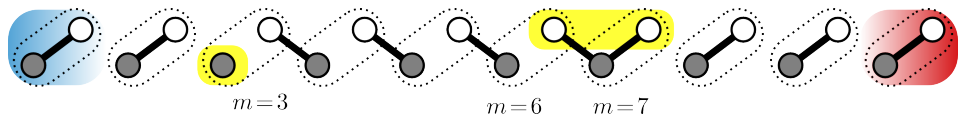

SSHは1次元模型であるため、エッジ状態は0次元（点）である。
一般に、$n$次元のトポロジカル絶縁体は、$(n-1)$次元のエッジ状態を持つ。<br>
ナノフォトニクスにおいては2次元のトポロジカル絶縁体が応用上重要であり、1次元のエッジ状態を導波モードとして利用することで、曲げ耐性や単一方向伝搬性を実現することができる。



## 実装

以上の議論をPythonによる実装で確認する。とはいっても7割方は[こちらのコピペ](https://github.com/oroszl/topins/blob/master/SSH.ipynb)。<br>
まずは必要なライブラリのインポートから。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

### 結合$v,w$と巻き付き数の対応

In [ ]:
kran=np.linspace(-np.pi,np.pi,201)
import ipywidgets

def dk(k,v,w,**kwargs):
    return [v+w*np.cos(k),w*np.sin(k),0]

@ipywidgets.interact(v=(-1,1,0.1),w=(-1,1,0.1))
def ekdk(v=0.5,w=0.5):
    dx,dy=dk(kran,v,w)[:2]
    #
    #-- This part makes the k-space figure--
    #
    plt.subplot(121)
    plt.plot(kran, np.sqrt(dx**2+dy**2),'k-',linewidth=3)           # This creates the
    plt.plot(kran,-np.sqrt(dx**2+dy**2),'k-',linewidth=3)          # two bandlines
    #just to make it look like in the book    
    plt.ylabel('energy E',fontsize=20);
    plt.xlabel(r'wavenumber $k$',fontsize=20);
    plt.xlim(-np.pi, np.pi); plt.xticks([-np.pi,0,np.pi],['$-\pi$','0','$\pi$'],fontsize=20)
    plt.ylim(-2.02,2.02);plt.yticks([-2,-1,0,1,2],['-2','-1','0','1','2'],fontsize=20);
    plt.plot(kran,0*kran,'k--')
    plt.plot([0,0],[-2.5,2.5],'k--')

    #
    #--This part makes the d-space figure--
    #
    plt.subplot(122)
    plt.plot(dx,dy,'k-',linewidth=3)                                # The d(k) line itself 
    plt.arrow(dx[30],dy[30],(dx[31]-dx[29])/30,(dy[31]-dy[29])/30,  # and an arrow
          head_width=0.15, head_length=0.2, fc='k', ec='k')     # showing winding direction
          
    #just to make it look like in the book 
    plt.plot([0],[0],'wo',markersize=20)
    if abs(v)==abs(w):                       # Here we have a simple criterion for 
        plt.plot([0],[0],'ro',markersize=10)     # metallicity
    plt.plot([1,1],[-0.1,0.1],'k')
    plt.plot([-1,-1],[-0.1,0.1],'k')
    plt.plot([-0.1,0.1],[1,1],'k')
    plt.plot([-0.1,0.1],[-1,-1],'k')
    plt.arrow(-2.0,0,3.6,0,head_width=0.2, head_length=0.4, fc='k', ec='k')
    plt.arrow(0,-1.5,0,2*1.4,head_width=0.2, head_length=0.4, fc='k', ec='k')
    plt.xlim(-2.1,2.1)
    plt.ylim(-2.1,2.1)
    plt.axis('off')
    plt.text(.9,-0.5,'1',fontsize=20); plt.text(-1.3,-0.5,'-1',fontsize=20);
    plt.text(-0.5,.9,'1',fontsize=20); plt.text(-0.7,-1.1,'-1',fontsize=20);
    plt.text(0.25,1.4,r'$d_y$',fontsize=20); plt.text(2,-0.5,r'$d_x$',fontsize=20);

### 有限系の計算

In [ ]:
def H_SSH_reals(L,v,w):
    idL=np.eye(L)
    odL=np.diag(np.ones(L-1),1)
    U=np.matrix([[0,1],[1,0]]) 
    T=np.matrix([[0,0],[1,0]]) 
    return np.kron(idL,v*U)+np.kron(odL,w*T)+np.kron(odL,w*T).H

L=20
dat=[]
vecdat=[]
vran=np.linspace(0,3,30)

for v in vran:
    w=1.0;
    H=H_SSH_reals(L,v,w)
    eigdat=np.linalg.eigh(H);      # for a given v here vi calculate the eigensystem (values and vectors)
    dat=np.append(dat,eigdat[0]);
    vecdat=np.append(vecdat,eigdat[1]);
    
dat=np.reshape(dat,[len(vran),2*L]);          # rewraping the data
vecdat=np.reshape(vecdat,[len(vran),2*L,2*L]) # to be more digestable

fs=15
plt.figure(figsize=(15,6))
@ipywidgets.interact(vi=(0,len(vran)-1),n=(0,2*L-1))
def enpsi(vi=10,n=L):
    plt.subplot(131)
    #plt.scatter(np.arange(dat.shape[1]), dat[vi], color="black");  
    dat_vi = dat[vi]
    dat_vi = dat_vi.reshape(-1,2)
    plt.scatter(np.arange(dat_vi.shape[0]), dat_vi[:,0], color="black");
    plt.scatter(np.arange(dat_vi.shape[0]), -dat_vi[:,1], color="black");

    plt.xlabel(r'$k$',fontsize=fs);
    plt.ylabel(r'$E$',fontsize=fs);
    #plt.yticks(fontsize=fs)
    plt.ylim(-2.99,2.99)
    #plt.grid()

    plt.subplot(132)
    plt.plot(vran,dat,'k-');    
    plt.plot(vran[vi],dat[vi,n],'ko',markersize=13)
    
    # Make it look like the book
    plt.xlabel(r'$v$',fontsize=fs);
    plt.xticks([0,1,2,3])#,fontsize=fs)
    plt.yticks(fontsize=fs)
    plt.ylim(-2.99,2.99)

    plt.subplot(133)
    plt.bar(np.array(range(0,2*L,2)),  np.abs(np.asarray(vecdat[vi][0::2, n]).ravel())**2,0.9,color='grey',label='A')  # sublattice A
    plt.bar(np.array(range(0,2*L,2))+1,np.abs(np.asarray(vecdat[vi][1::2, n]).ravel())**2,0.9,color='blue',label='B') # sublattice B    
    plt.ylim(0, 1.0)
    plt.yticks(np.linspace(-1,1,5))
    plt.ylabel(r'$|\psi|^2$',fontsize=fs, rotation=-90)
    #plt.grid()
    plt.legend(loc='lower right')
    plt.xlabel(r'cell index $m$',fontsize=fs);



### Zak phase の数値計算

数値固有ベクトルの位相は各 \(k\) で任意なので、Berry connection を有限差分して直接足し合わせる方法は不安定である。代わりに、閉じた離散波数列 \(k_0,\ldots,k_{N-1}\) に対して正規化したリンク変数

$$
U_{n,\pm}
=\frac{\langle u_\pm(k_n)\mid u_\pm(k_{n+1})\rangle}
{\left|\langle u_\pm(k_n)\mid u_\pm(k_{n+1})\rangle\right|},
\qquad k_N\equiv k_0
$$

を定義する。Wilson loop と Zak phase は

$$
W_\pm=\prod_{n=0}^{N-1}U_{n,\pm},
\qquad
\gamma_\pm=\operatorname{Arg}W_\pm
\quad (\mathrm{mod}\ 2\pi)
$$

で与えられる。リンクを絶対値で正規化することで、有限分割に由来する不要な振幅誤差を除き、位相だけを積算できる。最後の点と最初の点の重なりを必ず含める必要がある。


In [ ]:
def H_SSH(k,v,w,m=0):
    H = np.array([[m, v + w * np.e ** (-1.j * k)],
                  [v + w * np.e ** (1.j * k), -m]
                 ])
    return H

上の実装では、追加でChiral対称性を壊す項 $m$ を加えている。$m\neq 0$ のときにトポロジカル性が失われることを後ほど確認する。

$$
\begin{aligned}
H'(k) = 
\begin{bmatrix} 
    m & v + w e^{-ik} \\
    v + w e^{ik} & -m
\end{bmatrix} 
\end{aligned}
$$

各$k$に対して、固有値を計算。（COMSOLのパラメトリックスイープに対応）

In [ ]:
def gen_data(H, v, w, m=0.0, N=101):
    """Hermitian SSH model on N points in [-pi, pi)."""
    k_list = np.linspace(-np.pi, np.pi, N, endpoint=False)
    eigenvalues = []
    eigenvectors = []

    for k in k_list:
        Hamiltonian = H(k, v, w, m=m)
        E, U = np.linalg.eigh(Hamiltonian)
        eigenvalues.append(E)
        eigenvectors.append(U)

    eigenvectors = np.asarray(eigenvectors)
    return k_list, np.asarray(eigenvalues), eigenvectors, eigenvectors.copy()


グラフの描画

In [ ]:
def bnd_plot(k_list, eigenvalues, bandtype="Re", fs=18):
    plt.figure(figsize=(5,4))
    if bandtype == "Re":
        for i in range(len(eigenvalues[0])):
            plt.plot(k_list, eigenvalues[:,i].real)
    elif bandtype == "Im":
        for i in range(len(eigenvalues[0])):
            plt.plot(k_list, eigenvalues[:,i].imag)
    plt.xlabel(r"$k_x a$", fontsize=fs)
    plt.ylabel(bandtype + "$(E)$", fontsize=fs)
    plt.xticks(np.linspace(-np.pi, np.pi, 5), [r'$-\pi$', r'$-\pi/2$', r'$0$', r'$\pi/2$', r'$\pi$'], fontsize=fs)
    plt.tick_params(labelsize=fs*0.8)
    plt.show()

実行

In [ ]:
w = 1
v = 0.9#1.1#0.9
m = 0
N = 100

k_list, eigenvalues, npr_psiR, npr_psiL = gen_data(H_SSH, v, w, m=m, N=N)

#bnd_plot(k_list, eigenvalues, bandtype="Re")

### Wilson loop の計算

In [ ]:
def zak_phase_from_eigenvectors(eigenvectors, atol=1e-12):
    """Return one Zak phase per band in the interval [-pi, pi]."""
    n_k, _, n_band = eigenvectors.shape
    phases = np.zeros(n_band)

    for band in range(n_band):
        wilson_loop = 1.0 + 0.0j
        for n in range(n_k):
            u_n = eigenvectors[n, :, band]
            u_next = eigenvectors[(n + 1) % n_k, :, band]
            overlap = np.vdot(u_n, u_next)
            if abs(overlap) < atol:
                raise ValueError("Adjacent eigenvectors have nearly zero overlap.")
            wilson_loop *= overlap / abs(overlap)
        phases[band] = np.angle(wilson_loop)

    return phases

zak_phase = zak_phase_from_eigenvectors(npr_psiR)
print("Zak phase / pi:", zak_phase / np.pi)


In [ ]:
npr_psiL[:,:,0]

In [ ]:
phase_pi = np.angle(phase) / (np.pi)
#phase_pi = (phase_pi + 0.5) % 2 - 1
plt.plot(phase_pi)
#plt.plot(np.angle(list_denom))



上のコードを適当に弄ると、非エルミートな場合の計算も可能。各自試してみてください。

## 参考文献

- [Asbóth, János K., László Oroszlány, and András Pályi. "A short course on topological insulators." Lecture notes in physics 919 (2016)](https://arxiv.org/abs/1509.02295)
- [Fukui et al., "Chern numbers in discretized Brillouin zone: efficient method of computing (spin) Hall conductances." Journal of the Physical Society of Japan 74.6 (2005)](https://journals.jps.jp/doi/pdf/10.1143/JPSJ.74.1674)
- [筑波大学 数理物質科学研究科 物理学専攻　初貝安弘 グラフェンの物理](http://cms.phys.s.u-tokyo.ac.jp/pdf/HatsugaiAoki.pdf)
- [武内修＠筑波大 ベリー位相・ベリー接続・ベリー曲率](https://dora.bk.tsukuba.ac.jp/~takeuchi/?%E9%87%8F%E5%AD%90%E5%8A%9B%E5%AD%A6%2F%E3%83%99%E3%83%AA%E3%83%BC%E4%BD%8D%E7%9B%B8%E3%83%BB%E3%83%99%E3%83%AA%E3%83%BC%E6%8E%A5%E7%B6%9A%E3%83%BB%E3%83%99%E3%83%AA%E3%83%BC%E6%9B%B2%E7%8E%87)